## Feature Engineering 
- Impute missing numerical and categorical features 
- Drop constant and quasi-constant features 
- Carry out correlation analysis and remove highly correlated features 
- Statistical tests to remove insignificant features 
- One-hot and ordinal encoding of categorical features 
- Scale of continuous variables 


In [1]:
# import dependencies 
import pandas as pd 

filepath_xtrain = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/xtrain.csv" # filepath to train split 

filepath_ytrain = "/Users/thananpornsethjinda/Desktop/credit-risk-modeling/data/interim/ytrain.csv" # filepath to train split 

X_train = pd.read_csv(filepath_xtrain)

y_train = pd.read_csv(filepath_ytrain)

# your sginfiancne may have chnaged cuz you used a different splitting proportion 

### 1. Splitting into cross-validation splits

Since we will be using cross-validation in the later steps i.e model training and hyperparameter fine-tuning it is important that we do not carry out pre-processing and feature engineering on the entire train set as this will leak information into the validation set during cross-validation. Hence, we will split the training data into cross-validation splits while keeping the testing data untouched. Specifically, we will be using stratified k-fold cross-validation using the `StratifiedKFold` function from `sklearn` with `5` as the number of folds.

In [2]:
from sklearn.model_selection import StratifiedKFold

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

strat_splits = []

for train_index, val_index in splitter.split(X_train, y_train): 

    strat_train_set_n = X_train.iloc[train_index]

    strat_y_train_set_n = y_train.iloc[train_index]

    strat_val_set_n = X_train.iloc[val_index]

    strat_y_val_set_n = y_train.iloc[val_index]

    strat_splits.append([strat_train_set_n, strat_val_set_n, strat_y_train_set_n, strat_y_val_set_n])

In [3]:
# manual approach for one split 

strat_train_set_0, strat_val_set_0, strat_y_train_set_0, strat_y_val_set_0 = strat_splits[0]

In [4]:
strat_train_set_0.shape

(877545, 78)

In [5]:
y_train.shape

(1096932, 1)

### 2. Feature Selection/Feature Engineering Steps
- Impute missing numerical and categorical features 
- Drop constant and quasi-constant features 
- Carry out correlation analysis and remove highly correlated features 
- One-hot and ordinal encoding of categorical features 
- Scale of continuous variables

#### 2.1 Imputing Missing Numerical and Categorical Values

In [6]:
strat_train_set_0.select_dtypes(include=['object']).isnull().sum()

term                        0
sub_grade                   0
emp_length              51892
home_ownership              0
pymnt_plan                  0
application_type            0
disbursement_method         0
debt_settlement_flag        0
dtype: int64

In [7]:
CATEGORICAL_NA = ['emp_length']

In [8]:
from sklearn.impute import SimpleImputer

cat_imp = SimpleImputer(strategy="most_frequent")

strat_train_set_0.loc[:, CATEGORICAL_NA] = cat_imp.fit_transform(strat_train_set_0[CATEGORICAL_NA])

strat_val_set_0.loc[:, CATEGORICAL_NA] = cat_imp.transform(strat_val_set_0[CATEGORICAL_NA])

In [9]:
strat_val_set_0.head(2)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag
2,20000.0,20000.0,20000.0,36 months,11.99,664.20,B5,6 years,MORTGAGE,135000.0,...,100.0,50.0,0.0,0.0,594525.0,490924.0,14700.0,121625.0,Cash,N
3,7000.0,7000.0,7000.0,36 months,10.99,229.14,B4,10+ years,OWN,30000.0,...,89.6,NaN,0.0,0.0,41597.0,24425.0,0.0,19097.0,Cash,N


In [10]:
df = strat_train_set_0.select_dtypes(include=['float64']).isnull().sum()
NUMERICAL_NA = df.loc[df > 0].reset_index()['index'].to_list()

In [11]:
NUMERICAL_NA

['dti',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'revol_util',
 'collections_12_mths_ex_med',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'total_bal_il',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_il_tl',
 'num_op_rev_tl',
 'num_rev_accts',
 'num_rev_tl_bal_gt_0',
 'num_sats',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'num_tl_90g_dpd_24m',
 'num_tl_op_past_12m',
 'pct_tl_nvr_dlq',
 'percent_bc_gt_75',
 'pub_rec_bankruptcies',
 'tax_liens',
 'tot_hi_cred_lim',
 'total_bal_ex_mort',
 'total_bc_limit

In [12]:
num_imp = SimpleImputer(strategy="median")

strat_train_set_0.loc[:, NUMERICAL_NA] = num_imp.fit_transform(strat_train_set_0[NUMERICAL_NA])

strat_val_set_0.loc[:, NUMERICAL_NA] = num_imp.transform(strat_val_set_0[NUMERICAL_NA])

#### 2.2 Dropping Constant and Quasi-Constant Features

In [13]:
from feature_engine.selection import DropConstantFeatures

sel = DropConstantFeatures(tol=0.95)

strat_train_set_0 = sel.fit_transform(strat_train_set_0)

strat_val_set_0 = sel.transform(strat_val_set_0)

In [14]:
sel.features_to_drop_

['pymnt_plan',
 'collections_12_mths_ex_med',
 'policy_code',
 'application_type',
 'acc_now_delinq',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'tax_liens',
 'disbursement_method',
 'debt_settlement_flag']

#### 2.3 Correlation Analysis To Drop Highly Correlated Features

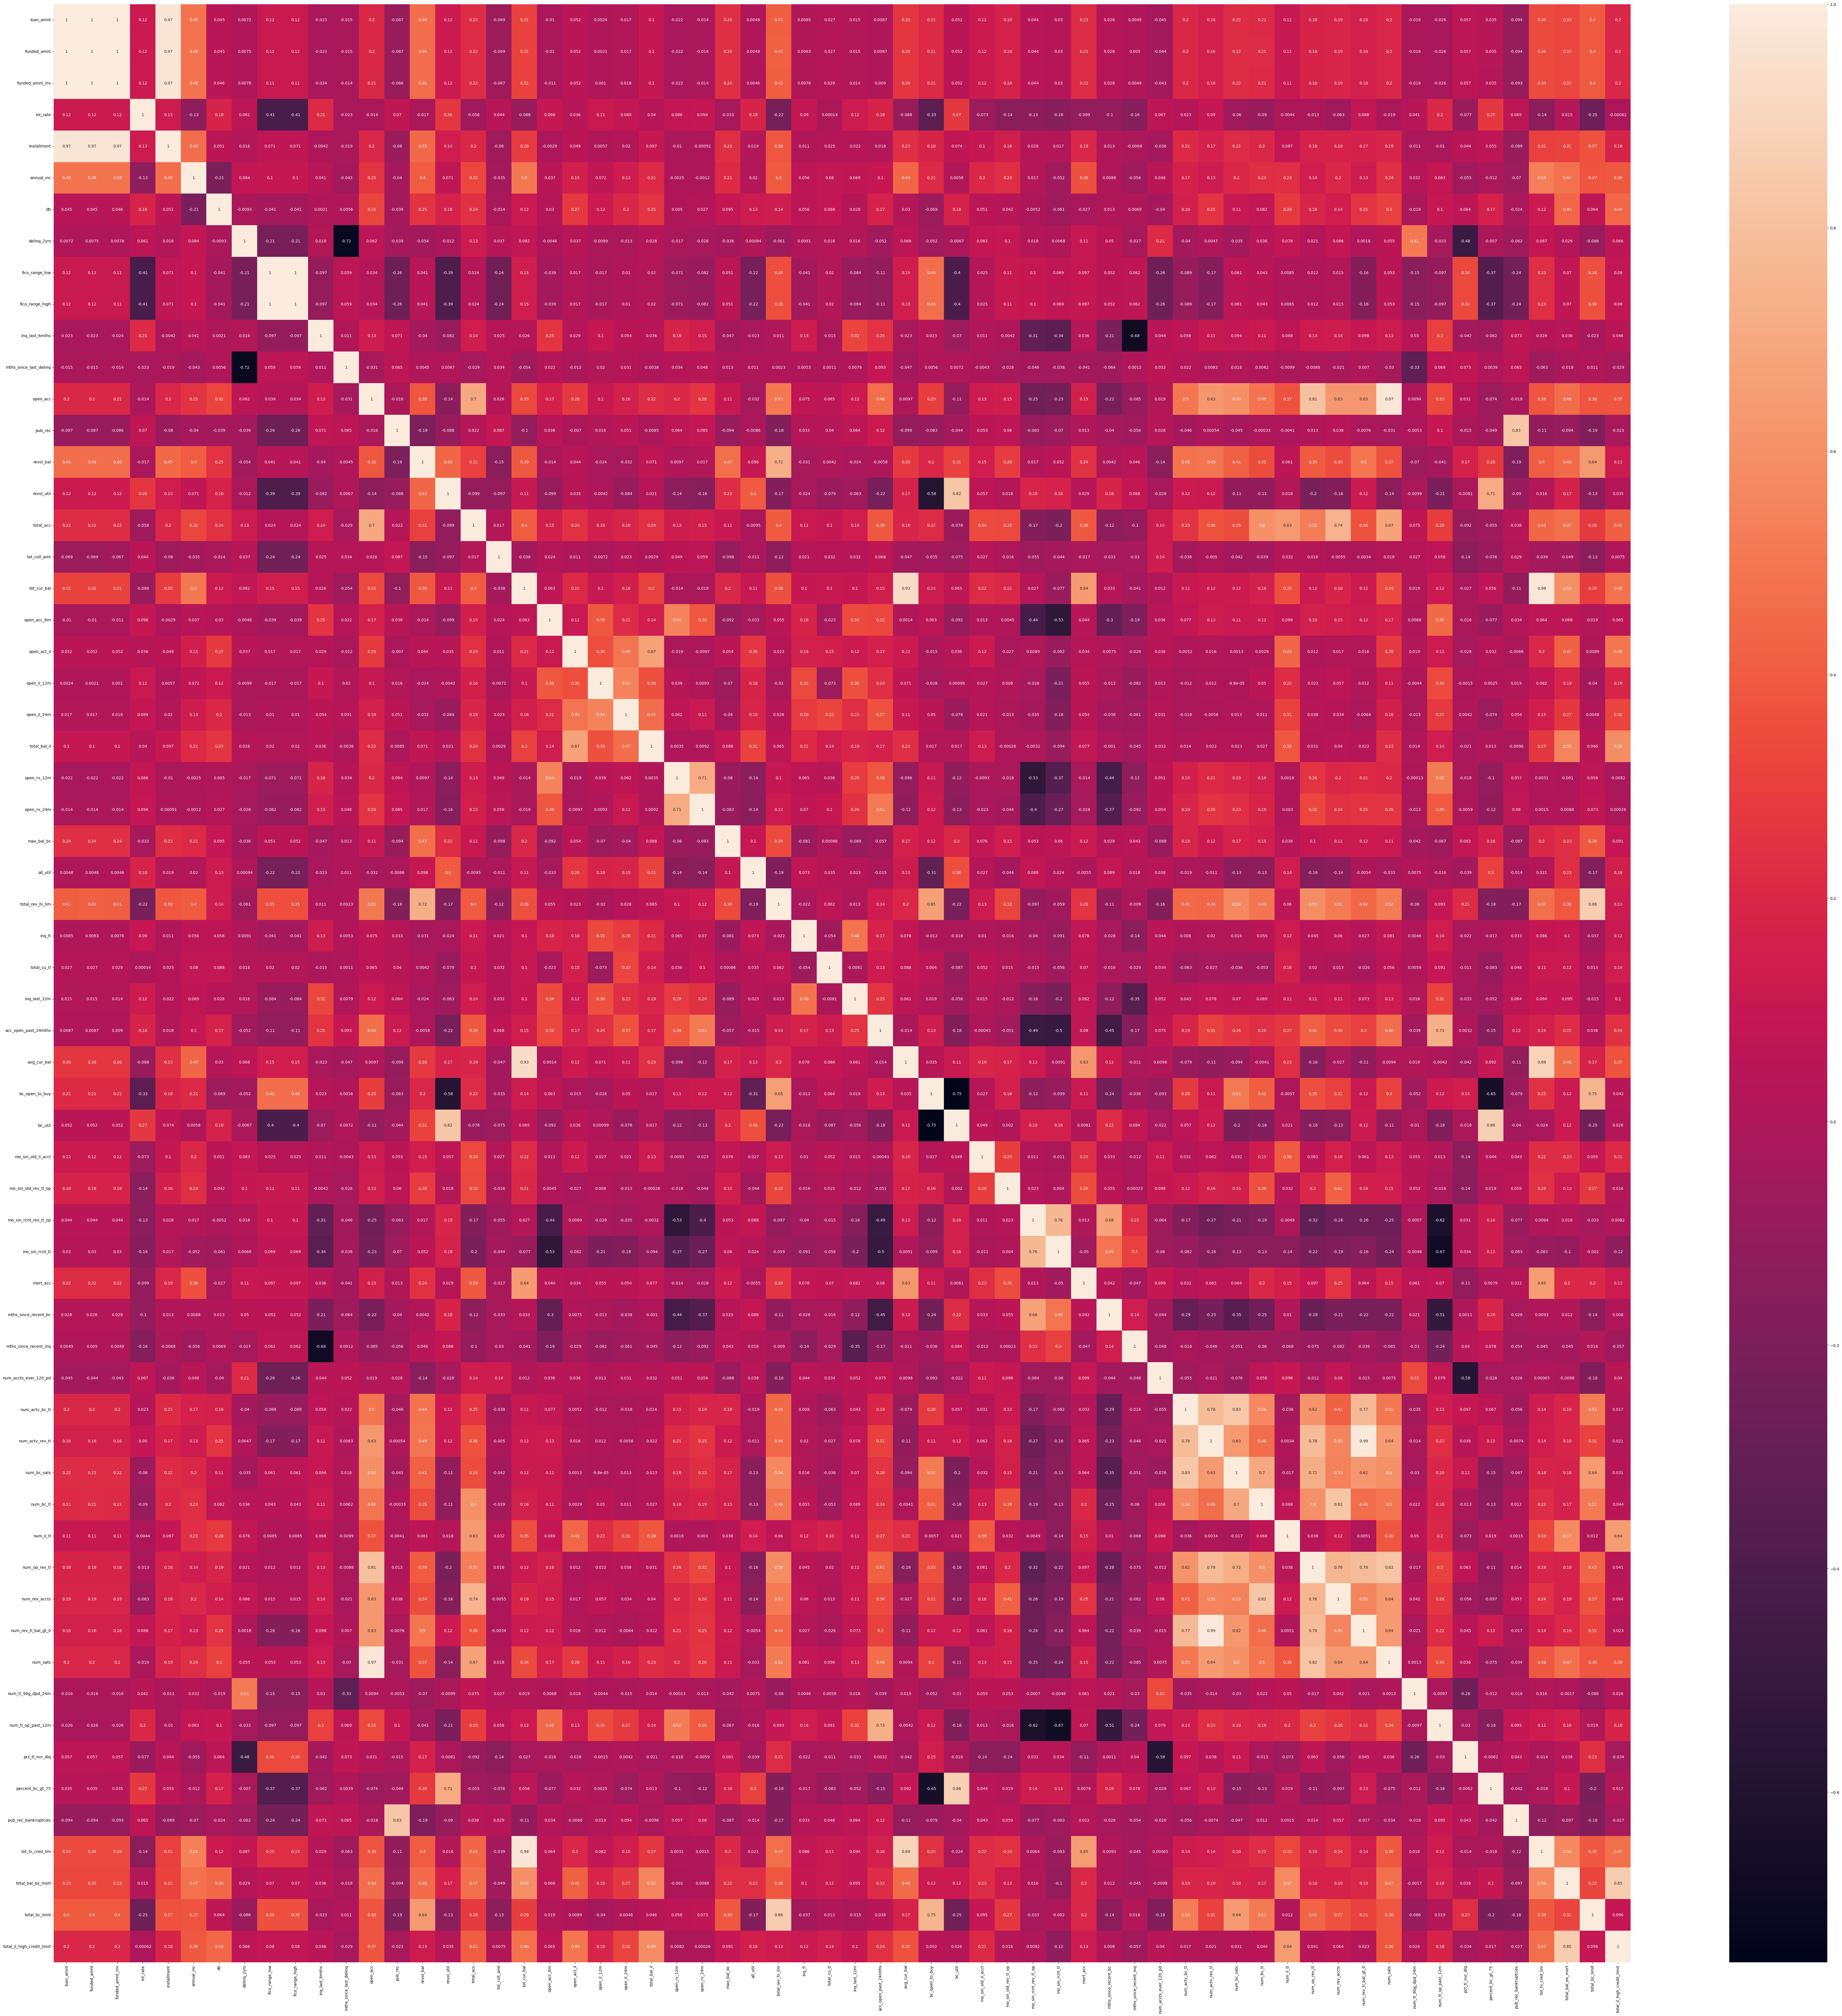

In [15]:
# correlation analysis of numerical features

import matplotlib.pyplot as plt 
import seaborn as sns

numerical_cleaned = strat_train_set_0.select_dtypes(include=['float64'])
corr_max = numerical_cleaned.corr(method="spearman")
plt.figure(figsize=(90, 90))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_max, annot=True)
plt.show()

In [16]:
pd.set_option('display.max_rows', 200)

feature_correlation_table = corr_max.abs().unstack()

# select highly correlated 
feature_correlation_table = feature_correlation_table[feature_correlation_table >= 0.8]

feature_correlation_table = pd.DataFrame(feature_correlation_table).reset_index()

feature_correlation_table.columns = ['feature1', 'feature2', 'corr']

# remove self correlations 

for index in range(feature_correlation_table.shape[0]): 

    if feature_correlation_table.loc[index, 'feature1'] == feature_correlation_table.loc[index, 'feature2']: 

        feature_correlation_table.drop(index=index, inplace=True)

feature_correlation_table

,feature1,feature2,corr
1,loan_amnt,funded_amnt,0.999642
2,loan_amnt,funded_amnt_inv,0.998140
3,loan_amnt,installment,0.968986
4,funded_amnt,loan_amnt,0.999642
6,funded_amnt,funded_amnt_inv,0.998611
7,funded_amnt,installment,0.969570
8,funded_amnt_inv,loan_amnt,0.998140
9,funded_amnt_inv,funded_amnt,0.998611
11,funded_amnt_inv,installment,0.968005
13,installment,loan_amnt,0.968986


In [ ]:
from feature_engine.selection import SmartCorrelatedSelection

corr_selection = SmartCorrelatedSelection(
    variables=None,
    method="spearman",
    threshold=0.8,
    missing_values="raise",
    selection_method="variance",
)

corr_selection.fit(strat_train_set_0)
strat_train_set_0 = corr_selection.transform(strat_train_set_0)
strat_val_set_0 = corr_selection.transform(strat_val_set_0)

In [18]:
corr_selection.features_to_drop_

['tot_cur_bal',
 'avg_cur_bal',
 'total_il_high_credit_limit',
 'total_bc_limit',
 'funded_amnt_inv',
 'funded_amnt',
 'installment',
 'bc_util',
 'fico_range_low',
 'num_bc_tl',
 'num_sats',
 'num_op_rev_tl',
 'num_rev_tl_bal_gt_0',
 'num_actv_bc_tl',
 'pub_rec_bankruptcies']

#### 2.4 Feature Encoding 

In [19]:
# encoding  

import numpy as np

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ONE_HOT_COLUMNS = ['term', 'home_ownership']

enc = OneHotEncoder(drop='first', sparse_output=False, dtype=np.int64)

enc.fit(strat_train_set_0[ONE_HOT_COLUMNS])

ONE_HOT_ENCODED_COLUMNS = list(enc.get_feature_names_out(ONE_HOT_COLUMNS))

strat_train_set_0[ONE_HOT_ENCODED_COLUMNS] = enc.transform(strat_train_set_0[ONE_HOT_COLUMNS])

strat_val_set_0[ONE_HOT_ENCODED_COLUMNS] = enc.transform(strat_val_set_0[ONE_HOT_COLUMNS])

In [20]:
ORDINAL_COLUMNS = ['sub_grade', 'emp_length']

ordinal_enc = OrdinalEncoder(dtype=np.int64)

ordinal_enc.fit(strat_train_set_0[ORDINAL_COLUMNS])

ORDINAL_ENCODED_COLUMNS = list(ordinal_enc.get_feature_names_out(ORDINAL_COLUMNS))

strat_train_set_0[ORDINAL_ENCODED_COLUMNS] = ordinal_enc.transform(strat_train_set_0[ORDINAL_COLUMNS])

strat_val_set_0[ORDINAL_ENCODED_COLUMNS] = ordinal_enc.transform(strat_val_set_0[ORDINAL_COLUMNS])


In [21]:
strat_train_set_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 877545 entries, 0 to 1096930
Data columns (total 57 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   loan_amnt                877545 non-null  float64
 1   term                     877545 non-null  object 
 2   int_rate                 877545 non-null  float64
 3   sub_grade                877545 non-null  int64  
 4   emp_length               877545 non-null  int64  
 5   home_ownership           877545 non-null  object 
 6   annual_inc               877545 non-null  float64
 7   dti                      877545 non-null  float64
 8   delinq_2yrs              877545 non-null  float64
 9   fico_range_high          877545 non-null  float64
 10  inq_last_6mths           877545 non-null  float64
 11  mths_since_last_delinq   877545 non-null  float64
 12  open_acc                 877545 non-null  float64
 13  pub_rec                  877545 non-null  float64
 14  revol_ba

In [22]:
strat_train_set_0 = strat_train_set_0.select_dtypes(exclude=['object'])
strat_val_set_0 = strat_val_set_0.select_dtypes(exclude=['object'])

In [23]:
strat_train_set_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 877545 entries, 0 to 1096930
Data columns (total 55 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   loan_amnt                877545 non-null  float64
 1   int_rate                 877545 non-null  float64
 2   sub_grade                877545 non-null  int64  
 3   emp_length               877545 non-null  int64  
 4   annual_inc               877545 non-null  float64
 5   dti                      877545 non-null  float64
 6   delinq_2yrs              877545 non-null  float64
 7   fico_range_high          877545 non-null  float64
 8   inq_last_6mths           877545 non-null  float64
 9   mths_since_last_delinq   877545 non-null  float64
 10  open_acc                 877545 non-null  float64
 11  pub_rec                  877545 non-null  float64
 12  revol_bal                877545 non-null  float64
 13  revol_util               877545 non-null  float64
 14  total_ac

In [24]:
strat_train_set_0.head(2)

,loan_amnt,int_rate,sub_grade,emp_length,annual_inc,dti,delinq_2yrs,fico_range_high,inq_last_6mths,mths_since_last_delinq,...,pct_tl_nvr_dlq,percent_bc_gt_75,tot_hi_cred_lim,total_bal_ex_mort,term_ 60 months,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
0,12000.0,9.17,6,3,48000.0,15.95,4.0,664.0,0.0,8.0,...,52.9,0.0,180546.0,7777.0,0,1,0,0,0,0
1,16000.0,11.53,9,2,44000.0,29.02,0.0,689.0,0.0,69.0,...,93.3,75.0,81332.0,61143.0,0,1,0,0,0,0


#### 2.5 Feature Scaling

In [25]:
# scaling 

from sklearn.preprocessing import RobustScaler

NUMERICAL_SCALE = strat_train_set_0.select_dtypes(exclude=['int64']).columns.to_list()

scale = RobustScaler()

strat_train_set_0[NUMERICAL_SCALE] = scale.fit_transform(strat_train_set_0[NUMERICAL_SCALE])

strat_val_set_0[NUMERICAL_SCALE] = scale.transform(strat_val_set_0[NUMERICAL_SCALE])

In [26]:
strat_train_set_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 877545 entries, 0 to 1096930
Data columns (total 55 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   loan_amnt                877545 non-null  float64
 1   int_rate                 877545 non-null  float64
 2   sub_grade                877545 non-null  int64  
 3   emp_length               877545 non-null  int64  
 4   annual_inc               877545 non-null  float64
 5   dti                      877545 non-null  float64
 6   delinq_2yrs              877545 non-null  float64
 7   fico_range_high          877545 non-null  float64
 8   inq_last_6mths           877545 non-null  float64
 9   mths_since_last_delinq   877545 non-null  float64
 10  open_acc                 877545 non-null  float64
 11  pub_rec                  877545 non-null  float64
 12  revol_bal                877545 non-null  float64
 13  revol_util               877545 non-null  float64
 14  total_ac

#### 2.6 Selecting Top Features Using Mutual Information Criterion

Text(0.5, 1.0, 'Mutual information between predictors and target')

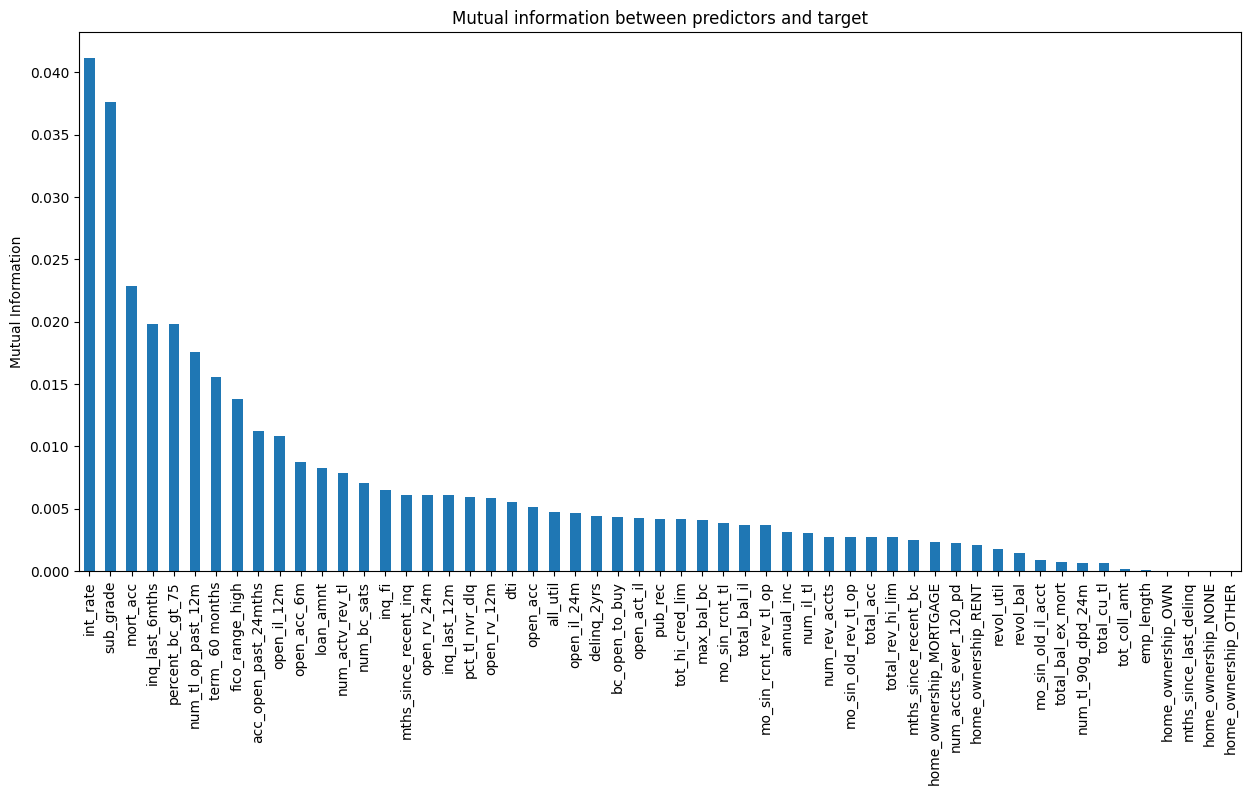

In [27]:
# mutual information 

masking = []
for column in strat_train_set_0.columns: 
    if column in ONE_HOT_ENCODED_COLUMNS + ORDINAL_ENCODED_COLUMNS: 
        masking.append(True)
    else:
        masking.append(False)

from sklearn.feature_selection import mutual_info_classif

mi_stuff = mutual_info_classif(strat_train_set_0, strat_y_train_set_0['loan_status'], discrete_features=masking, random_state=42)

mi = pd.Series(mi_stuff)
mi.index = strat_train_set_0.columns
mi.sort_values(ascending=False).plot.bar(figsize=(15, 7))
plt.ylabel('Mutual Information')
plt.title("Mutual information between predictors and target")

In [ ]:
# ['int_rate', 'fico_range_high', 'inq_last_6mths', 'open_il_12m',
#        'acc_open_past_24mths', 'mort_acc', 'num_tl_op_past_12m',
#        'percent_bc_gt_75', 'term_ 60 months', 'sub_grade'

### 3. Pipeline Orchestration of Feature Engineering/Feature Selection Steps

So far, we have carried out the feature engineering/feature selection steps on only one cross-validation split. We want to carry out the steps above on all splits to find out the best set of features selected from all the cross-validation splits. In order to do that, we can wrap our steps above into a neat `Pipeline` object.

In [58]:
# reset tp the original form of the split 

strat_train_set_0, strat_val_set_0, strat_y_train_set_0, strat_y_val_set_0 = strat_splits[0]

In [57]:
strat_train_set_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 877545 entries, 0 to 1096930
Data columns (total 78 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   877545 non-null  float64
 1   funded_amnt                 877545 non-null  float64
 2   funded_amnt_inv             877545 non-null  float64
 3   term                        877545 non-null  object 
 4   int_rate                    877545 non-null  float64
 5   installment                 877545 non-null  float64
 6   sub_grade                   877545 non-null  object 
 7   emp_length                  877545 non-null  object 
 8   home_ownership              877545 non-null  object 
 9   annual_inc                  877545 non-null  float64
 10  pymnt_plan                  877545 non-null  object 
 11  dti                         877545 non-null  float64
 12  delinq_2yrs                 877545 non-null  float64
 13  fico_range_low    

In [ ]:
# pipeline for the same split 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from src.data.features import MutualInfoSelector
from sklearn._config import set_config

set_config(transform_output="pandas")

impute = ColumnTransformer(
    [
        ("numerical_imputation", SimpleImputer(strategy='median'), make_column_selector(dtype_include=np.float64)), 
        ("categorical_impuutation", SimpleImputer(strategy='most_frequent'), make_column_selector(dtype_include=[object, "string"]))
    ], 
    remainder='passthrough', 
    verbose=True, 
    verbose_feature_names_out=False
)

encode = ColumnTransformer(
    [
        ("one_hot_encoding", OneHotEncoder(drop='first', sparse_output=False, dtype=np.int64), ['term', 'home_ownership']), 
        ("ordinal_encoding", OrdinalEncoder(dtype=np.int64), ['sub_grade', 'emp_length']), 
    ],
    remainder='passthrough', 
    verbose=True, 
    verbose_feature_names_out=False
)

scale = make_column_transformer(
    (RobustScaler(), make_column_selector(dtype_exclude=np.int64)),
    remainder='passthrough', 
    verbose=True, 
    verbose_feature_names_out=False
)


pipeline = Pipeline([
    # numerical and categorical imputation 

    ("imputation", impute), 

    # remove constant q-constant 

    ("removing_constant_features", DropConstantFeatures(tol=0.95)),

    # remove correlated 

    ("correlation_analysis", SmartCorrelatedSelection(
    variables=None,
    method="spearman",
    threshold=0.8,
    missing_values="raise",
    selection_method="variance")),

    # encoding and scaling

    ("encode", encode),

    ("robust_scaling", scale),

    ("mututal_information_selector", MutualInfoSelector(k=10, categorical_features=ONE_HOT_COLUMNS+ORDINAL_COLUMNS))
])

pipeline.fit(strat_train_set_0, strat_y_train_set_0['loan_status'])
feature_names_out = pipeline.get_feature_names_out()

feature_names_out

[ColumnTransformer]  (1 of 2) Processing numerical_imputation, total=  10.1s
[ColumnTransformer]  (2 of 2) Processing categorical_impuutation, total=   0.7s
[ColumnTransformer]  (1 of 3) Processing one_hot_encoding, total=   0.4s
[ColumnTransformer]  (2 of 3) Processing ordinal_encoding, total=   0.3s
[ColumnTransformer] ..... (3 of 3) Processing remainder, total=   0.0s
[ColumnTransformer] .. (1 of 2) Processing robustscaler, total=   1.6s
[ColumnTransformer] ..... (2 of 2) Processing remainder, total=   0.0s
Index(['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'tot_coll_amt', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'total_bal_il', 'open_rv_12m', 'open_rv_24m',
       'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl',
       'inq_last_12m', 'acc_open_past_24mths', 'bc_open_to_buy

array(['int_rate', 'fico_range_high', 'inq_last_6mths', 'open_il_12m',
       'acc_open_past_24mths', 'mort_acc', 'num_tl_op_past_12m',
       'percent_bc_gt_75', 'term_ 60 months', 'sub_grade'], dtype=object)

### 4. Performing Feature Selection On All Other Splits

In [66]:
len(strat_splits)

5

In [ ]:
# pipeline for all other splits 

for index in range(len(strat_splits)): 

    strat_train_set, strat_val_set, strat_y_train_set, strat_y_val_set= strat_splits[index]

    pipeline.fit(strat_train_set, strat_y_train_set['loan_status'])
    feature_names_out = pipeline.get_feature_names_out()

    print(f'Features from split {index}: {feature_names_out}')
    print("=="*30)



[ColumnTransformer]  (1 of 2) Processing numerical_imputation, total=  11.4s
[ColumnTransformer]  (2 of 2) Processing categorical_impuutation, total=   0.7s
[ColumnTransformer]  (1 of 3) Processing one_hot_encoding, total=   0.4s
[ColumnTransformer]  (2 of 3) Processing ordinal_encoding, total=   0.3s
[ColumnTransformer] ..... (3 of 3) Processing remainder, total=   0.0s
[ColumnTransformer] .. (1 of 2) Processing robustscaler, total=   1.5s
[ColumnTransformer] ..... (2 of 2) Processing remainder, total=   0.0s
Index(['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'delinq_2yrs',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'tot_coll_amt', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'total_bal_il', 'open_rv_12m', 'open_rv_24m',
       'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl',
       'inq_last_12m', 'acc_open_past_24mths', 'bc_open_to_buy

: 

### 5. Finalisation of Features 

In [ ]:
# get final features 

['int_rate' 'fico_range_high' 'inq_last_6mths' 'open_il_12m'
 'acc_open_past_24mths' 'mort_acc' 'num_tl_op_past_12m' 'percent_bc_gt_75'
 'term_ 60 months' 'sub_grade']